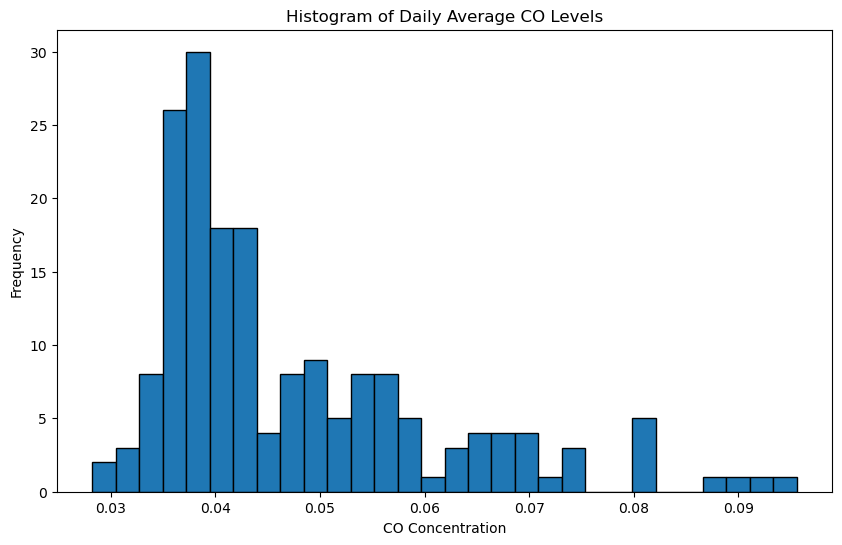

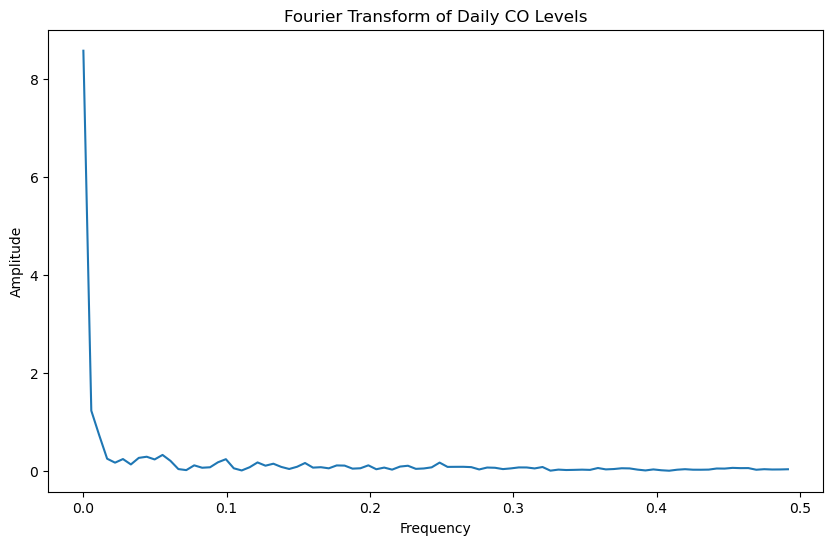

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0210 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0118 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0106 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0102 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0093 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0090 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0088 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0086 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0088 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 10/5

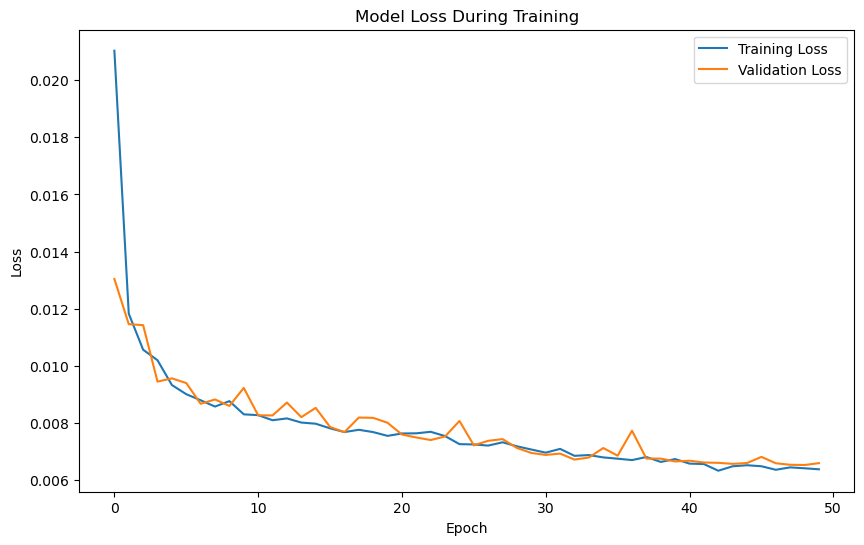

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
RMSE: 0.0061
MAE: 0.0044
R²: 0.8165


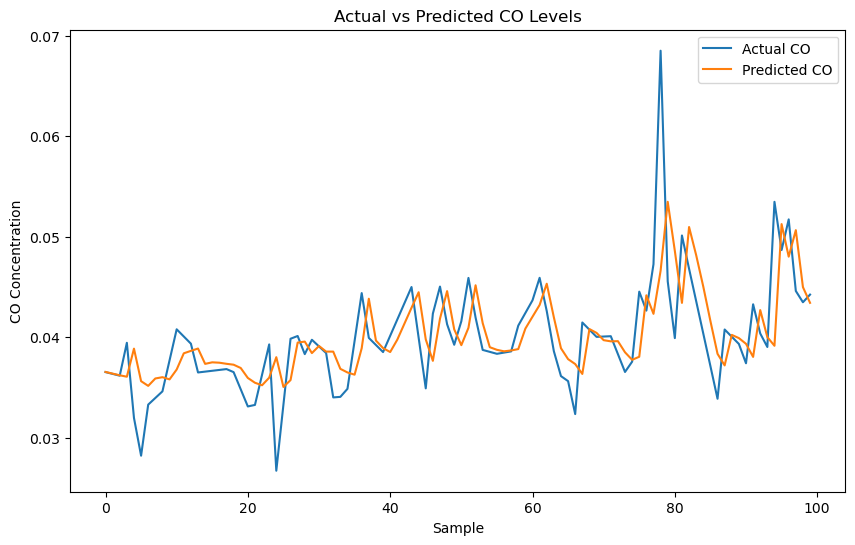


7-Day CO Forecast:
        date  Sensor_1  Sensor_2  Sensor_3  Sensor_4  Sensor_5  Sensor_6  \
0 2024-04-30  0.062021  0.060652  0.061518  0.062609  0.060605  0.060482   
1 2024-05-01  0.062346  0.060621  0.061339  0.063410  0.060839  0.060513   
2 2024-05-02  0.062536  0.061088  0.061603  0.063765  0.061380  0.061011   
3 2024-05-03  0.064568  0.063209  0.063658  0.065727  0.063533  0.063139   
4 2024-05-04  0.068501  0.067237  0.067628  0.069613  0.067621  0.067174   
5 2024-05-05  0.073434  0.072244  0.072626  0.074413  0.072673  0.072185   
6 2024-05-06  0.076853  0.075339  0.076078  0.077768  0.075588  0.075188   

   Sensor_7  Sensor_8  Sensor_9  ...  Sensor_21  Sensor_22  Sensor_23  \
0  0.061214  0.062239  0.062671  ...   0.061786   0.061525   0.060978   
1  0.061001  0.062644  0.063570  ...   0.063248   0.062488   0.061699   
2  0.061389  0.062767  0.063991  ...   0.063894   0.062840   0.062124   
3  0.063512  0.064739  0.065946  ...   0.066057   0.064574   0.064135   
4  0.0

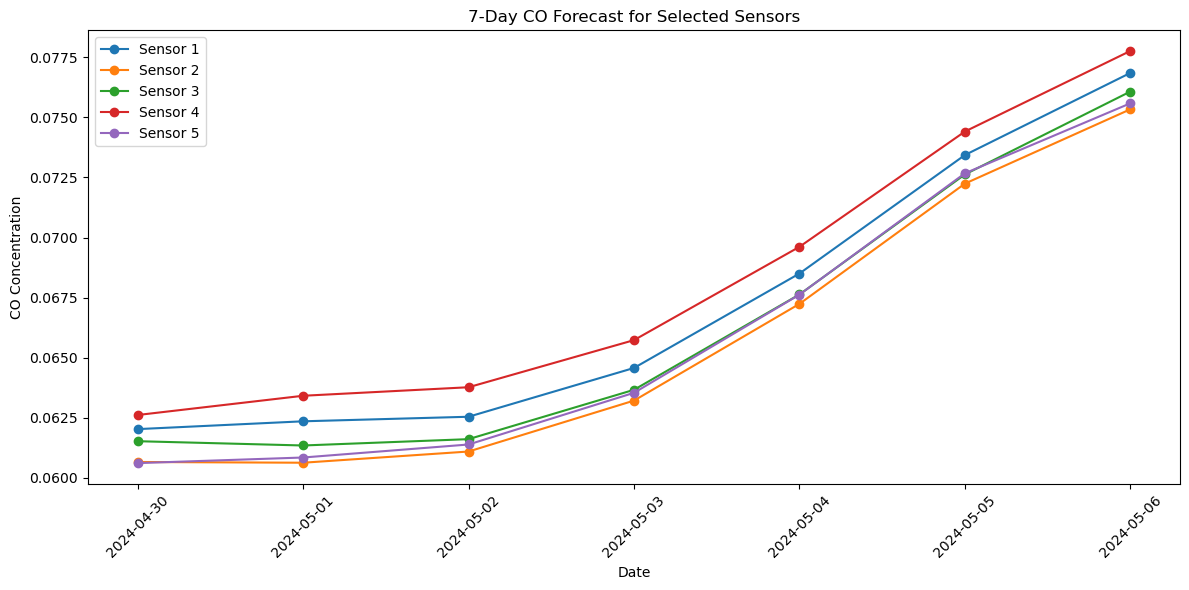


Sample 7-Day Forecast for Sensor 1:
        Date  Sensor_1_Forecast
0 2024-04-30           0.062021
1 2024-05-01           0.062346
2 2024-05-02           0.062536
3 2024-05-03           0.064568
4 2024-05-04           0.068501
5 2024-05-05           0.073434
6 2024-05-06           0.076853


In [10]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import save_model, load_model
from tensorflow.keras.losses import MeanSquaredError
import io
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('CO_hex30_urban.csv') 

# Ensure 'date' column exists
if 'date' not in df.columns:
    raise KeyError("The 'date' column is missing from the input data")

# Converting date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sorting data by sensor ID and date
df = df.sort_values(['id', 'date'])

# Handling missing values with time-based interpolation for each sensor
df['CO'] = df['CO'].replace('NA', np.nan)

# Fixed interpolation: set index to date for each group and interpolate
def interpolate_sensor(group):
    if 'date' not in group.columns:
        raise KeyError("The 'date' column is missing in the sensor group")
    group = group.set_index('date')
    group['CO'] = group['CO'].interpolate(method='time')
    group = group.reset_index()  # Ensure 'date' is returned as a column
    return group

# Apply interpolation while preserving DataFrame structure
df = df.groupby('id', group_keys=False).apply(interpolate_sensor)

# Verify 'date' column exists after interpolation
if 'date' not in df.columns:
    raise KeyError("The 'date' column is missing after interpolation")

# Drop any remaining NaN values (e.g., at the beginning)
df = df.dropna(subset=['CO'])

# Calculating daily average CO levels
daily_avg = df.groupby('date')['CO'].mean().reset_index()

# Plotting histogram of daily CO values
plt.figure(figsize=(10, 6))
plt.hist(daily_avg['CO'], bins=30, edgecolor='black')
plt.title('Histogram of Daily Average CO Levels')
plt.xlabel('CO Concentration')
plt.ylabel('Frequency')
plt.show()

# Performing Fourier transform to analyze trends
from numpy.fft import fft, fftfreq
fft_values = fft(daily_avg['CO'].values)
frequencies = fftfreq(len(fft_values))
plt.figure(figsize=(10, 6))
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_values)[:len(frequencies)//2])
plt.title('Fourier Transform of Daily CO Levels')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.show()

# Preparing data for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Scaling data
scaler = MinMaxScaler()
df['CO_scaled'] = scaler.fit_transform(df[['CO']])

# Creating sequences for each sensor
seq_length = 7  # Using 7 days as sequence length
X, y = [], []
for sensor_id in df['id'].unique():
    sensor_data = df[df['id'] == sensor_id]['CO_scaled'].values
    if len(sensor_data) >= seq_length + 1:
        X_sensor, y_sensor = create_sequences(sensor_data, seq_length)
        X.append(X_sensor)
        y.append(y_sensor)

if len(X) == 0:
    raise ValueError("Not enough data for sequences after interpolation")

X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

# Splitting data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Building the LSTM model
model = Sequential([
    Bidirectional(LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(50, activation='relu')),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss=MeanSquaredError())

# Setting up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Reshaping data for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Training the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test),
                    callbacks=[early_stopping, reduce_lr], verbose=1)

# Plotting training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluating the model
y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# Calculating performance metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')

# Plotting actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_inv[:100], label='Actual CO')
plt.plot(y_pred_inv[:100], label='Predicted CO')
plt.title('Actual vs Predicted CO Levels')
plt.xlabel('Sample')
plt.ylabel('CO Concentration')
plt.legend()
plt.show()

# Forecasting the next 7 days
last_date = df['date'].max()
forecast_dates = [last_date + timedelta(days=i) for i in range(1, 8)]
forecasts = []

# Using the last sequence from each sensor for forecasting
for sensor_id in df['id'].unique():
    sensor_data = df[df['id'] == sensor_id]['CO_scaled'].values[-seq_length:]
    if len(sensor_data) < seq_length:
        # Pad with last value if not enough data
        pad_length = seq_length - len(sensor_data)
        padded = np.full(pad_length, sensor_data[-1] if len(sensor_data) > 0 else 0)
        sensor_data = np.concatenate((padded, sensor_data))
    current_sequence = sensor_data[-seq_length:].reshape((1, seq_length, 1))
    sensor_forecast = []
    
    for _ in range(7):
        next_pred = model.predict(current_sequence, verbose=0)
        sensor_forecast.append(next_pred[0, 0])
        current_sequence = np.roll(current_sequence, -1, axis=1)
        current_sequence[0, -1, 0] = next_pred[0, 0]
    
    sensor_forecast = scaler.inverse_transform(np.array(sensor_forecast).reshape(-1, 1))
    forecasts.append({'id': sensor_id, 'forecast': sensor_forecast.flatten()})

# Creating forecast DataFrame
forecast_dict = {f'Sensor_{int(f["id"])}': f['forecast'] for f in forecasts}
forecast_df = pd.DataFrame({'date': forecast_dates})
for col in forecast_dict:
    forecast_df[col] = forecast_dict[col]

# Displaying forecast results
print("\n7-Day CO Forecast:")
print(forecast_df)

# Plotting forecast for a few sensors
plt.figure(figsize=(12, 6))
num_sensors_to_plot = min(5, len(df['id'].unique()))
for i, sensor_id in enumerate(df['id'].unique()[:num_sensors_to_plot]):
    plt.plot(forecast_df['date'], forecast_df[f'Sensor_{int(sensor_id)}'], label=f'Sensor {int(sensor_id)}', marker='o')
plt.title('7-Day CO Forecast for Selected Sensors')
plt.xlabel('Date')
plt.ylabel('CO Concentration')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Saving the model
model.save('co_lstm_model.h5')

# Loading and using the model for prediction (demonstration)
loaded_model = load_model('co_lstm_model.h5')
# Example: Predicting using the last sequence of sensor 1
sensor_1_data = df[df['id'] == 1]['CO_scaled'].values[-seq_length:]
if len(sensor_1_data) < seq_length:
    pad_length = seq_length - len(sensor_1_data)
    padded = np.full(pad_length, sensor_1_data[-1] if len(sensor_1_data) > 0 else 0)
    sensor_1_data = np.concatenate((padded, sensor_1_data))
sample_sequence = sensor_1_data[-seq_length:].reshape((1, seq_length, 1))
sample_forecast = []
for _ in range(7):
    pred = loaded_model.predict(sample_sequence, verbose=0)
    sample_forecast.append(pred[0, 0])
    sample_sequence = np.roll(sample_sequence, -1, axis=1)
    sample_sequence[0, -1, 0] = pred[0, 0]
sample_forecast = scaler.inverse_transform(np.array(sample_forecast).reshape(-1, 1))

# Displaying sample forecast for sensor 1
sample_forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Sensor_1_Forecast': sample_forecast.flatten()
})
print("\nSample 7-Day Forecast for Sensor 1:")
print(sample_forecast_df)